# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
# Inspect the shapes of the datasets
print("X_train shape:", X_train.shape) 
print("y_train shape:", y_train.shape)   
print("X_test shape:", X_test.shape)     
print("y_test shape:", y_test.shape) 

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [3]:
# Convert labels to one-hot encoding
import numpy as np
from tensorflow.keras.utils import to_categorical

def one_hot(n_classes, y):
    return np.eye(n_classes)[y]

y_train = one_hot(10, y_train)
y_test = one_hot(10, y_test)


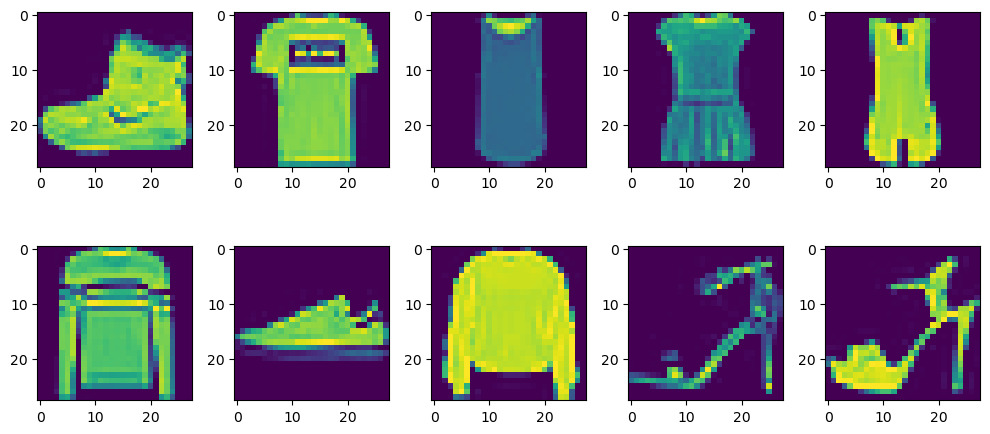

In [4]:
import matplotlib.pyplot as plt
# Verify the data looks as expected
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28))
plt.tight_layout()
plt.show()


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

10 images of apparel items as expected, each image is 28x28 as expected and coded.
Images are very low quality.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [5]:
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.optimizers import SGD, Adam

# Create a simple linear regression model
model_baseline = Sequential()

# You can use `model.add(<layer>)` to add layers to the model
model_baseline.add(Flatten(input_shape=(28, 28, 1)))
#model_baseline.add(Dense(64, activation='relu', input_shape=(64,)))  -- making this change will make it linear
#model_baseline.add(Dense(64, activation='relu'))  -- making this change will make it linear
model_baseline.add(Dense(10))

# Compile the model using `model.compile()`
model_baseline.compile(
    loss='categorical_crossentropy',  
    optimizer=SGD(learning_rate=0.01),  
    metrics=['accuracy']
)

# Train the model with `model.fit()`
model_baseline.fit(
    X_train, 
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

c:\Users\baran-pc\miniconda3\envs\dsi_participant\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1137 - loss: 7.9280 - val_accuracy: 0.1027 - val_loss: 6.5823
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1015 - loss: 6.7301 - val_accuracy: 0.1027 - val_loss: 7.2883
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1017 - loss: 7.6492 - val_accuracy: 0.1027 - val_loss: 6.6211
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0997 - loss: 6.4024 - val_accuracy: 0.1027 - val_loss: 6.4100
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0997 - loss: 6.3241 - val_accuracy: 0.1027 - val_loss: 6.2447
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0996 - loss: 6.4787 - val_accuracy: 0.1027 - val_loss: 6.2500
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0973 - loss: 6.4277 - val_accuracy: 0.1027 - val_loss: 6.3970
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0974 - loss: 6.4342 - 

In [6]:
# Evaluate the model with `model.evaluate()`

loss, accuracy = model_baseline .evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1062 - loss: 7.2617
Loss:     7.35
Accuracy: 10.00%


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

The baseline model has a 10.00% accuracy with a loss of 7.35. This is expected from a simple linear regression model. The code lacks any hidden layers or non-linear activation functions, making it difficult to learn complex patterns. Using SGD optimizer is also has a fixed learning rate and is quite rigid at learning compared to Adam.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [7]:
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Flatten())
#model.add(Dense(64, activation='relu')) # you can remove this dense layer for speed
model.add(Dense(10, activation='softmax'))  


# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.01),
    metrics=['accuracy']
)

# Train the model with `model.fit()`
model.fit(
    X_train, 
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10


c:\Users\baran-pc\miniconda3\envs\dsi_participant\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8208 - loss: 0.5400 - val_accuracy: 0.8723 - val_loss: 0.3539
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8879 - loss: 0.3059 - val_accuracy: 0.8861 - val_loss: 0.3351
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9054 - loss: 0.2648 - val_accuracy: 0.8756 - val_loss: 0.3752
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9158 - loss: 0.2340 - val_accuracy: 0.8751 - val_loss: 0.3797
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9216 - loss: 0.2183 - val_accuracy: 0.8789 - val_loss: 0.4031
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9264 - loss: 0.2009 - val_accuracy: 0.8765 - val_loss: 0.4151
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9306 - loss: 0.1896 - val_accuracy: 0.8672 - val_loss: 0.4596
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9342 - loss: 0.1762 - val

In [8]:
# Evaluate the model with `model.evaluate()`

loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8684 - loss: 0.6175
Loss:     0.61
Accuracy: 87.03%


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

The CNN model performed substantially better than the baseline model, as this model had an accuracy of 87.03% and a loss of 0.61. The increase in accuracy can be attributed to 2D converstion and the softmax dense layer which better allows for non-linear learning. Switching to an Adam opitmizer may have also contributed to this as it automatically adjusts the learning rate based on how the training is going.

# 4. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [9]:
from keras.layers import Dropout

# Create a loop that tests the following permutations:
# Regularization technique -  Model with and without a dropout layer of 0.3 (tried with 0.2 in previous submission and it wasnt great)
# Hyperparameter options - Modes with 32, 64, 128 filters 
# this will give us 6 model options to compare and choose from for question 5

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Define hyperparameter & regularization options
filter_sizes = [32, 64, 128]
dropout_layer = [False, True]
results = []

# Create for loop
for filters in filter_sizes:
    for dropout in dropout_layer:
        model_test = Sequential()
        model_test.add(Conv2D(filters, kernel_size=(3,3), activation='relu', input_shape = (28, 28, 1)))
        model_test.add(Flatten())

        if dropout:
            model_test.add(Dropout(0.3))
        
        model_test.add(Dense(10, activation='softmax'))

        # Compile the model
        model_test.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.01),
        metrics=['accuracy']
        )
        
        # Train the model with `model.fit()`
        history = model_test.fit(
        X_train, 
        y_train,
        epochs=10, 
        batch_size=32,
        validation_split=0.2
        )

        test_loss, test_accuracy = model_test.evaluate(X_test, y_test, verbose=0)

        results.append({
            'filters': filters,
            'dropout': dropout,
            'test_loss': f"{test_loss:.2f}",
            'test_accuracy (%)':f"{test_accuracy * 100:.2f}"
        })


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8160 - loss: 0.5554 - val_accuracy: 0.8733 - val_loss: 0.3563
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8881 - loss: 0.3101 - val_accuracy: 0.8802 - val_loss: 0.3403
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9083 - loss: 0.2537 - val_accuracy: 0.8752 - val_loss: 0.3577
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9176 - loss: 0.2251 - val_accuracy: 0.8803 - val_loss: 0.3804
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9239 - loss: 0.2080 - val_accuracy: 0.8739 - val_loss: 0.4123
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9310 - loss: 0.1864 - val_accuracy: 0.8825 - val_loss: 0.4236
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9364 - loss: 0.1743 - val_accuracy: 0.8762 - val_loss: 0.4602
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9370 - loss: 0

In [10]:
# Convert results to DataFrame and Compre
import pandas as pd

results_df = pd.DataFrame(results)
print(results_df)

   filters  dropout test_loss test_accuracy (%)
0       32    False      0.63             87.10
1       32     True      0.43             86.35
2       64    False      0.60             86.05
3       64     True      0.46             86.91
4      128    False      0.61             87.39
5      128     True      0.44             87.04


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

In my model_test experiment, the loop above tests the following permutations:
- Regularization Technique: test model with and without a dropout layer of 0.3
- Hyperparamterization Technique: test model with the following number of filters --> 32, 62 and 128

The loop took a very long time to run . The results tell us that model with 128 number of filters and a dropout layer of 0.3 had the best performance, as it had the highest accuracy (87.39%) and the lowest loss (0.43) out of the 6 tests. The variance of acraccy and loss across the tests were small, with an accuracy range of 1.34 % pts and a loss range of 0.2 pts.

Adding a dropout layer to a model with 128 filters gave us the best performing model but the model with 128 filters and no dropout layer gave us the worse performing model in terms of accuracy.
Another thing to note is that adding a dropout layer consistently improved performance, likely combatting overfitting and allowing for more generalization.


# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [11]:
# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create the final  CNN model w greater filter count, greater kernel size and dropout of 0.2
model_final = Sequential()
model_final.add(Conv2D(128, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model_final.add(Flatten())
model_final.add(Dropout(0.3))
#model_final.add(Dense(128, activation='relu'))  
model_final.add(Dense(10, activation='softmax'))  


# Compile the model
model_final.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.01),
    metrics=['accuracy']
)

# Train the model with `model.fit()`
history_final = model_final.fit(
    X_train, 
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

c:\Users\baran-pc\miniconda3\envs\dsi_participant\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.8029 - loss: 0.6448 - val_accuracy: 0.8595 - val_loss: 0.3897
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.8750 - loss: 0.3517 - val_accuracy: 0.8719 - val_loss: 0.3507
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.8849 - loss: 0.3153 - val_accuracy: 0.8717 - val_loss: 0.3546
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.8918 - loss: 0.3022 - val_accuracy: 0.8738 - val_loss: 0.3704
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.8912 - loss: 0.2921 - val_accuracy: 0.8774 - val_loss: 0.3689
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 34ms/step - accuracy: 0.8918 - loss: 0.2947 - val_accuracy: 0.8596 - val_loss: 0.4076
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 34ms/step - accuracy: 0.8961 - loss: 0.2822 - val_accuracy: 0.8732 - val_loss: 0.3886
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9015 -

In [12]:
final_loss, final_accuracy = model_final.evaluate(X_test, y_test)

print(f'Loss:     {final_loss:.2f}')
print(f'Accuracy: {final_accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8753 - loss: 0.4244
Loss:     0.42
Accuracy: 87.46%


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**



Below are the results compared to the baseline mode we ran in question 2 (model_baseline) and the original CNN model we ran in question 3 (model):

Baseline Model (model_baseline)
- Loss:     7.35
- Accuracy: 10.00%

Original CNN (model)
- Loss:     0.61
- Accuracy: 87.03%

Final CNN (model_final)
- Loss:     0.42
- Accuracy: 87.46%



The final model outperforms the baseline linear model and slightly improves on the original CNN in both loss and accuracy. Using the Adam optimizer, increasing the number of filters, and adding a dropout layer enhanced spatial pattern learning and improved generalization, reducing overfitting.

The main trade-off is runtime: the first CNN trained in about 2 minutes, while the final model took about 8 minutes. With more time, I’d explore reducing training time without sacrificing accuracy—for example, running fewer epochs if validation loss plateaus earlier, and tuning kernel sizes and the dense layer to see whether similar performance can be achieved more efficiently


🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.